<a href="https://colab.research.google.com/github/mbrinkl5/ECGR-4106---Introduction-to-Deep-Learning/blob/main/ECGR4106_Homework_5_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework 5**

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, datasets
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch.nn.functional as F
import matplotlib.pyplot as plt

import datetime
import os
import tensorflow as tf
import time

from tqdm import tqdm

In [ ]:
!pip install thop

In [ ]:
!pip install torchinfo

In [ ]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CIFAR-100 dataloader

In [ ]:
# Hyperparameters
image_size = 32
patch_size = 4
num_classes = 100
num_epochs = 10
batch_size = 64
learning_rate = 0.001
num_heads = 8
num_layers = 8
hidden_dim = 256
mlp_dim = 1024

In [ ]:
# Data preparation
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [ ]:
# CIFAR-100 dataset
train_dataset = torchvision.datasets.CIFAR100(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR100(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 169M/169M [1:10:42<00:00, 39.8kB/s]


In [ ]:
# Data loaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [ ]:
# Hyperparameters
image_size = 32
patch_size = 4
num_classes = 100
num_epochs = 10
batch_size = 64
learning_rate = 0.001
num_heads = 8
num_layers = 8
hidden_dim = 256
mlp_dim = 1024

# Problem 1: Vision Transformer from Scratch vs. ResNet-18

In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_size, patch_size, in_channels=3, embed_dim=256):
        super().__init__()
        self.num_patches = (image_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim,
                            kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)  # [B, embed_dim, H', W']
        x = x.flatten(2)  # [B, embed_dim, num_patches]
        x = x.transpose(1, 2)  # [B, num_patches, embed_dim]
        return x

In [ ]:
# Transformer Encoder
class TransformerEncoder(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.layer_norm1 = nn.LayerNorm(embed_dim)
        self.attention = nn.MultiheadAttention( embed_dim,num_heads, dropout=dropout,batch_first=True)
        self.layer_norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x2 = self.layer_norm1(x)
        attention_output, _ = self.attention(x2, x2, x2)
        x = x + attention_output
        x2 = self.layer_norm2(x)
        mlp_output = self.mlp(x2)
        x = x + mlp_output
        return x

In [ ]:
# Vision Transformer
class VisionTransformer(nn.Module):
    def __init__(self, image_size, patch_size, num_classes, embed_dim,
                 num_heads, num_layers, mlp_dim, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(image_size, patch_size, 3, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        num_patches = (image_size // patch_size) ** 2
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)

        self.transformer = nn.ModuleList(
            [TransformerEncoder(embed_dim, num_heads, mlp_dim, dropout)
             for _ in range(num_layers)]
        )

        self.layer_norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.dropout(x)

        for transformer in self.transformer:
            x = transformer(x)

        x = self.layer_norm(x)
        cls_token_final = x[:, 0]
        x = self.head(cls_token_final)
        return x


# Training Code -

In [ ]:
# Initialize model
model = VisionTransformer(
    image_size=image_size,
    patch_size=patch_size,
    num_classes=num_classes,
    embed_dim=hidden_dim,
    num_heads=num_heads,
    num_layers=num_layers,
    mlp_dim=mlp_dim
).to(device)

In [ ]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
def train():
    model.train()
    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if (i+1) % 100 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}], Loss: {loss.item():.4f}')

In [ ]:
# Training loop
def train():
    from thop import profile # Added import for 'profile'
    print("\nStarting training...")
    start_time_total = time.time()

    # Lists to store metrics for plotting
    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_accuracies = []

    # Number of parameters
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total trainable parameters: {total_params}")

    # FLOPs
    dummy_input = torch.randn(1, 3, image_size, image_size).to(device)
    macs, params = profile(model, inputs=(dummy_input,), verbose=False)
    print(f"Average FLOPs (MACs): {macs / 1e9:.2f} GFLOPS")

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for i, (images, labels) in enumerate(tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs} Training')):
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        epoch_train_losses.append(avg_train_loss)
        print(f"Epoch {epoch + 1} finished. Average training loss: {avg_train_loss:.4f}")

        # Validation after each epoch
        val_loss, val_accuracy, avg_inference_time = evaluate(model, test_loader, criterion, device, phase='Validation')
        epoch_val_losses.append(val_loss)
        epoch_val_accuracies.append(val_accuracy)
        print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%')
        print(f'Average Inference Time per Batch (Validation): {avg_inference_time:.4f} seconds')

    end_time_total = time.time()
    print(f"\nTraining finished in {(end_time_total - start_time_total):.2f} seconds")
    print(f"Final Training Loss: {avg_train_loss:.4f}")

    return epoch_train_losses, epoch_val_losses, epoch_val_accuracies

In [ ]:
def evaluate(model, data_loader, criterion, device, phase='Test'):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    inference_times = []

    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc=f'{phase} Phase'):
            images = images.to(device)
            labels = labels.to(device)

            start_time = time.time()
            outputs = model(images)
            end_time = time.time()

            inference_times.append(end_time - start_time)

            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = running_loss / len(data_loader)
    accuracy = 100 * correct / total
    avg_inference_time = sum(inference_times) / len(inference_times) if inference_times else 0

    print(f'{phase} Loss: {avg_loss:.4f}, {phase} Accuracy: {accuracy:.2f}%')
    print(f'Average Inference Time per Batch ({phase}): {avg_inference_time:.4f} seconds')

    return avg_loss, accuracy, avg_inference_time

In [ ]:
train_losses, val_losses, val_accuracies = train()


Starting training...
Total trainable parameters: 6373732
Average FLOPs (MACs): 0.27 GFLOPS


Epoch 1/10 Training: 100%|██████████| 782/782 [00:30<00:00, 25.33it/s]


Epoch 1 finished. Average training loss: 2.4730


Validation Phase: 100%|██████████| 157/157 [00:03<00:00, 41.21it/s]


Validation Loss: 2.6609, Validation Accuracy: 31.99%
Average Inference Time per Batch (Validation): 0.0046 seconds
Validation Loss: 2.6609, Validation Accuracy: 31.99%
Average Inference Time per Batch (Validation): 0.0046 seconds


...

Validation Loss: 2.6144, Validation Accuracy: 35.62%
Average Inference Time per Batch (Validation): 0.0045 seconds
Validation Loss: 2.6144, Validation Accuracy: 35.62%
Average Inference Time per Batch (Validation): 0.0045 seconds


Epoch 10/10 Training: 100%|██████████| 782/782 [00:30<00:00, 25.41it/s]


Epoch 10 finished. Average training loss: 1.5014


Validation Phase: 100%|██████████| 157/157 [00:03<00:00, 41.85it/s]

Validation Loss: 2.6555, Validation Accuracy: 36.93%
Average Inference Time per Batch (Validation): 0.0045 seconds
Validation Loss: 2.6555, Validation Accuracy: 36.93%
Average Inference Time per Batch (Validation): 0.0045 seconds

Training finished in 346.11 seconds
Final Training Loss: 1.5014


In [ ]:
print("\nFinal Evaluation on Test Set:")
test_loss, test_accuracy, test_inference_time = evaluate(model, test_loader, criterion, device, phase='Test')
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')
print(f'Average Inference Time per Batch (Test): {test_inference_time:.4f} seconds')


Final Evaluation on Test Set:


Test Phase: 100%|██████████| 157/157 [00:03<00:00, 40.11it/s]

Test Loss: 2.6555, Test Accuracy: 36.93%
Average Inference Time per Batch (Test): 0.0046 seconds
Test Loss: 2.6555, Test Accuracy: 36.93%
Average Inference Time per Batch (Test): 0.0046 seconds


In [ ]:
import torch
from thop import profile

# Calculate number of parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

# Calculate FLOPs
# We need a dummy input to calculate FLOPs.
# The input should match the expected input shape of the model.
dummy_input = torch.randn(1, 3, image_size, image_size).to(device)
macs, params = profile(model, inputs=(dummy_input,), verbose=False) # verbose=False to suppress detailed output
print(f"Average FLOPs (MACs): {macs / 1e9:.2f} GFLOPS") # Convert to GFLOPS

Total trainable parameters: 6373732
Average FLOPs (MACs): 0.27 GFLOPS


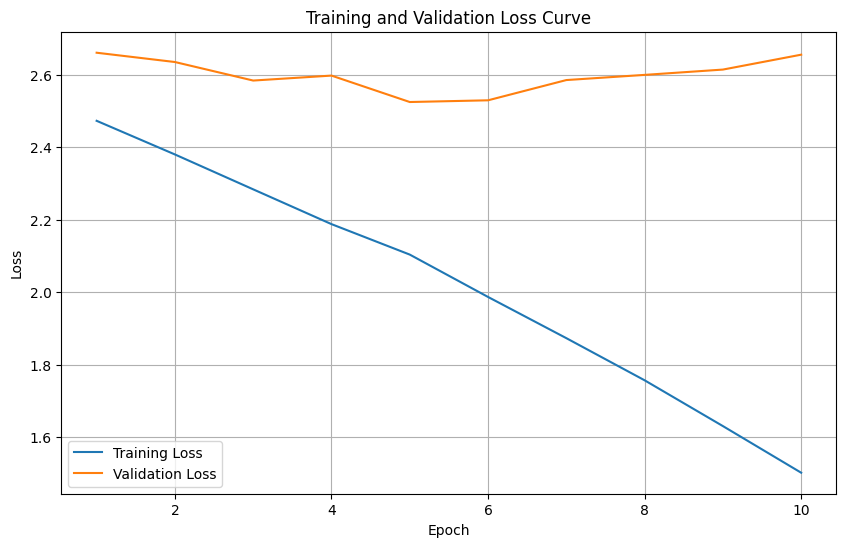

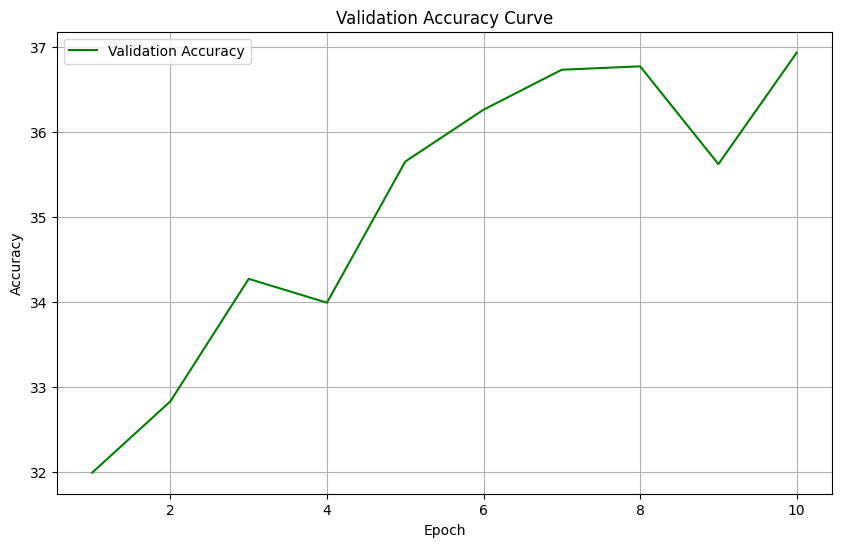

In [ ]:
import matplotlib.pyplot as plt

# Define epochs based on the length of the collected loss data
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()

# **Problem 2 - Fine-Tuning Pretrained Swin Transformers vs. Training from Scratch**

# Tiny Pretrained

In [ ]:
from torch.utils.data import DataLoader
from transformers import SwinForImageClassification, SwinConfig, AutoImageProcessor
from tqdm import tqdm

In [ ]:
image_size = 224
patch_size = 4
num_classes = 100
num_epochs = 5
batch_size = 32
learning_rate = 2e-5

In [ ]:
processor = AutoImageProcessor.from_pretrained("microsoft/swin-tiny-patch4-window7-224")

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

In [ ]:
imagenet_mean = processor.image_mean
imagenet_std = processor.image_std

In [ ]:
# Data preparation
# Training transform
train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# Test transform
test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])


In [ ]:
# CIFAR-100 datasets
train_dataset = torchvision.datasets.CIFAR100(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR100(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

100%|██████████| 169M/169M [53:34<00:00, 52.6kB/s]


In [ ]:
# Data loaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
model = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224",
    num_labels=100,
    ignore_mismatched_sizes=True
).to(device)

config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

[transformers] You passed `num_labels=100` which is incompatible to the `id2label` map of length `1000`.


model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
# Freeze backbone parameters and only train the classification head
for param in model.swin.parameters():
    param.requires_grad = False

# Only the classifier head will be trained
for param in model.classifier.parameters():
    param.requires_grad = True


In [ ]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=learning_rate)

In [ ]:
def evaluate(model, data_loader, criterion, device, phase='Test'):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    inference_times = []

    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc=f'{phase} Phase'):
            images = images.to(device)
            labels = labels.to(device)

            start_time = time.time()
            outputs = model(images)
            end_time = time.time()

            inference_times.append(end_time - start_time)

            # Adapt to model output type: check if 'outputs' has a 'logits' attribute
            if hasattr(outputs, 'logits'):
                current_logits = outputs.logits
            else:
                current_logits = outputs

            loss = criterion(current_logits, labels)
            running_loss += loss.item()

            _, predicted = torch.max(current_logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = running_loss / len(data_loader)
    accuracy = 100 * correct / total
    avg_inference_time = sum(inference_times) / len(inference_times) if inference_times else 0

    print(f'{phase} Loss: {avg_loss:.4f}, {phase} Accuracy: {accuracy:.2f}%')
    print(f'Average Inference Time per Batch ({phase}): {avg_inference_time:.4f} seconds')

    return avg_loss, accuracy, avg_inference_time

In [ ]:
# Training loop
def train():
    from thop import profile # Added import for 'profile'
    print("\nStarting training...")
    start_time_total = time.time()

    # Lists to store metrics for plotting
    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_accuracies = []

    # Number of parameters (already calculated, but can be printed here for context)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total trainable parameters: {total_params}")

    # FLOPs (assuming thop is installed and calculated previously)
    dummy_input = torch.randn(1, 3, image_size, image_size).to(device)
    macs, params = profile(model, inputs=(dummy_input,), verbose=False)
    print(f"Average FLOPs (MACs): {macs / 1e9:.2f} GFLOPS")

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for i, (images, labels) in enumerate(tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs} Training')):
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs.logits, labels) # Extract logits from the output object

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        epoch_train_losses.append(avg_train_loss)
        print(f"Epoch {epoch + 1} finished. Average training loss: {avg_train_loss:.4f}")

        # Validation after each epoch
        val_loss, val_accuracy, avg_inference_time = evaluate(model, test_loader, criterion, device, phase='Validation')
        epoch_val_losses.append(val_loss)
        epoch_val_accuracies.append(val_accuracy)
        print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%')
        print(f'Average Inference Time per Batch (Validation): {avg_inference_time:.4f} seconds')

    end_time_total = time.time()
    print(f"\nTraining finished in {(end_time_total - start_time_total):.2f} seconds")
    print(f"Final Training Loss: {avg_train_loss:.4f}")

    return epoch_train_losses, epoch_val_losses, epoch_val_accuracies

In [ ]:
train_losses, val_losses, val_accuracies = train()


Starting training...
Total trainable parameters: 76900
Average FLOPs (MACs): 4.36 GFLOPS


Epoch 1/5 Training: 100%|██████████| 1563/1563 [00:53<00:00, 29.33it/s]


Epoch 1 finished. Average training loss: 4.0671


Validation Phase: 100%|██████████| 313/313 [00:10<00:00, 30.24it/s]


Validation Loss: 3.5013, Validation Accuracy: 46.51%
Average Inference Time per Batch (Validation): 0.0154 seconds
Validation Loss: 3.5013, Validation Accuracy: 46.51%
Average Inference Time per Batch (Validation): 0.0154 seconds


...

Validation Loss: 1.7901, Validation Accuracy: 64.68%
Average Inference Time per Batch (Validation): 0.0152 seconds
Validation Loss: 1.7901, Validation Accuracy: 64.68%
Average Inference Time per Batch (Validation): 0.0152 seconds


Epoch 5/5 Training: 100%|██████████| 1563/1563 [00:52<00:00, 29.68it/s]


Epoch 5 finished. Average training loss: 1.6746


Validation Phase: 100%|██████████| 313/313 [00:10<00:00, 30.50it/s]

Validation Loss: 1.5759, Validation Accuracy: 66.33%
Average Inference Time per Batch (Validation): 0.0151 seconds
Validation Loss: 1.5759, Validation Accuracy: 66.33%
Average Inference Time per Batch (Validation): 0.0151 seconds

Training finished in 317.77 seconds
Final Training Loss: 1.6746


In [ ]:
print("\nFinal Evaluation on Test Set:")
test_loss, test_accuracy, test_inference_time = evaluate(model, test_loader, criterion, device, phase='Test')
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')
print(f'Average Inference Time per Batch (Test): {test_inference_time:.4f} seconds')


Final Evaluation on Test Set:


Test Phase: 100%|██████████| 313/313 [00:10<00:00, 29.47it/s]

Test Loss: 1.5759, Test Accuracy: 66.33%
Average Inference Time per Batch (Test): 0.0153 seconds
Test Loss: 1.5759, Test Accuracy: 66.33%
Average Inference Time per Batch (Test): 0.0153 seconds


In [ ]:
import torch
from thop import profile

# Calculate number of parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

# Calculate FLOPs
# We need a dummy input to calculate FLOPs.
# The input should match the expected input shape of the model.
dummy_input = torch.randn(1, 3, image_size, image_size).to(device)
macs, params = profile(model, inputs=(dummy_input,), verbose=False) # verbose=False to suppress detailed output
print(f"Average FLOPs (MACs): {macs / 1e9:.2f} GFLOPS") # Convert to GFLOPS

Total trainable parameters: 76900
Average FLOPs (MACs): 4.36 GFLOPS


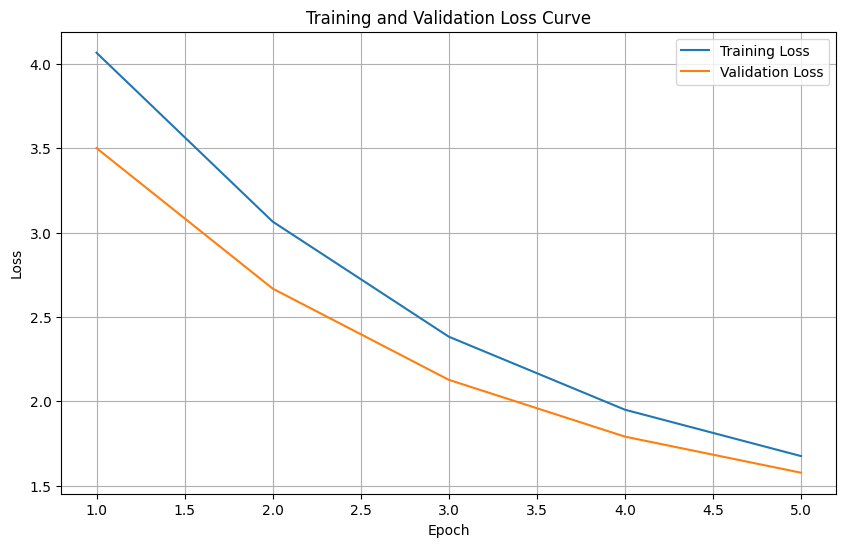

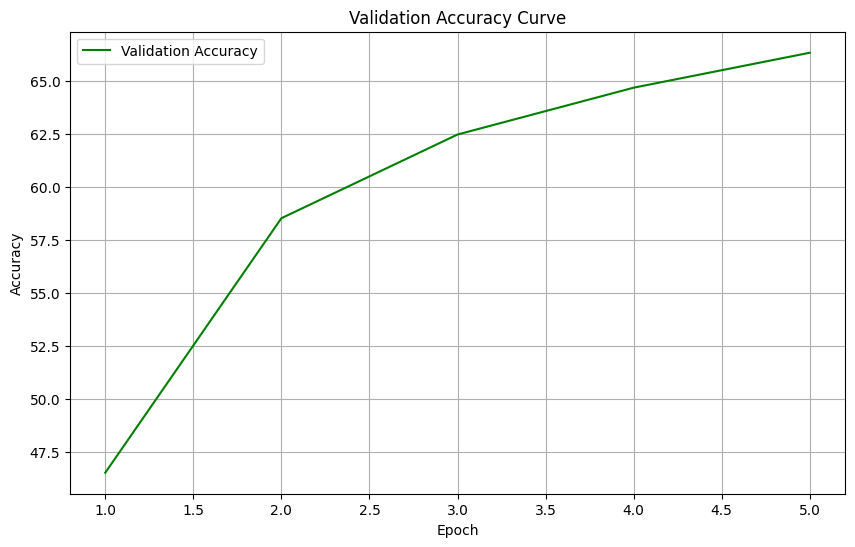

In [ ]:
import matplotlib.pyplot as plt

# Define epochs based on the length of the collected loss data
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()

# Small Pretrained

In [ ]:
model = SwinForImageClassification.from_pretrained(
    "microsoft/swin-small-patch4-window7-224",
    num_labels=100,
    ignore_mismatched_sizes=True
).to(device)

config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

[transformers] You passed `num_labels=100` which is incompatible to the `id2label` map of length `1000`.


pytorch_model.bin:   0%|          | 0.00/199M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/425 [00:00<?, ?it/s]

[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-small-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
# Freeze backbone parameters and only train the classification head
for param in model.swin.parameters():
    param.requires_grad = False

# Only the classifier head will be trained
for param in model.classifier.parameters():
    param.requires_grad = True


In [ ]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=learning_rate)

In [ ]:
def evaluate(model, data_loader, criterion, device, phase='Test'):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    inference_times = []

    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc=f'{phase} Phase'):
            images = images.to(device)
            labels = labels.to(device)

            start_time = time.time()
            outputs = model(images)
            end_time = time.time()

            inference_times.append(end_time - start_time)

            # Adapt to model output type: check if 'outputs' has a 'logits' attribute
            if hasattr(outputs, 'logits'):
                current_logits = outputs.logits
            else:
                current_logits = outputs

            loss = criterion(current_logits, labels)
            running_loss += loss.item()

            _, predicted = torch.max(current_logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = running_loss / len(data_loader)
    accuracy = 100 * correct / total
    avg_inference_time = sum(inference_times) / len(inference_times) if inference_times else 0

    print(f'{phase} Loss: {avg_loss:.4f}, {phase} Accuracy: {accuracy:.2f}%')
    print(f'Average Inference Time per Batch ({phase}): {avg_inference_time:.4f} seconds')

    return avg_loss, accuracy, avg_inference_time

In [ ]:
# Training loop
def train():
    from thop import profile # Added import for 'profile'
    print("\nStarting training...")
    start_time_total = time.time()

    # Lists to store metrics for plotting
    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_accuracies = []

    # Number of parameters (already calculated, but can be printed here for context)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total trainable parameters: {total_params}")

    # FLOPs (assuming thop is installed and calculated previously)
    dummy_input = torch.randn(1, 3, image_size, image_size).to(device)
    macs, params = profile(model, inputs=(dummy_input,), verbose=False)
    print(f"Average FLOPs (MACs): {macs / 1e9:.2f} GFLOPS")

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for i, (images, labels) in enumerate(tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs} Training')):
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs.logits, labels) # Use outputs directly

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        epoch_train_losses.append(avg_train_loss)
        print(f"Epoch {epoch + 1} finished. Average training loss: {avg_train_loss:.4f}")

        # Validation after each epoch
        val_loss, val_accuracy, avg_inference_time = evaluate(model, test_loader, criterion, device, phase='Validation')
        epoch_val_losses.append(val_loss)
        epoch_val_accuracies.append(val_accuracy)
        print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%')
        print(f'Average Inference Time per Batch (Validation): {avg_inference_time:.4f} seconds')

    end_time_total = time.time()
    print(f"\nTraining finished in {(end_time_total - start_time_total):.2f} seconds")
    print(f"Final Training Loss: {avg_train_loss:.4f}")

    return epoch_train_losses, epoch_val_losses, epoch_val_accuracies

In [ ]:
train_losses, val_losses, val_accuracies = train()


Starting training...
Total trainable parameters: 76900
Average FLOPs (MACs): 8.53 GFLOPS


Epoch 1/5 Training: 100%|██████████| 1563/1563 [01:26<00:00, 17.97it/s]


Epoch 1 finished. Average training loss: 3.9994


Validation Phase: 100%|██████████| 313/313 [00:17<00:00, 17.77it/s]


Validation Loss: 3.3814, Validation Accuracy: 51.71%
Average Inference Time per Batch (Validation): 0.0321 seconds
Validation Loss: 3.3814, Validation Accuracy: 51.71%
Average Inference Time per Batch (Validation): 0.0321 seconds


...

Validation Loss: 1.5871, Validation Accuracy: 68.74%
Average Inference Time per Batch (Validation): 0.0318 seconds
Validation Loss: 1.5871, Validation Accuracy: 68.74%
Average Inference Time per Batch (Validation): 0.0318 seconds


Epoch 5/5 Training: 100%|██████████| 1563/1563 [01:27<00:00, 17.96it/s]


Epoch 5 finished. Average training loss: 1.4762


Validation Phase: 100%|██████████| 313/313 [00:17<00:00, 18.07it/s]

Validation Loss: 1.3880, Validation Accuracy: 70.42%
Average Inference Time per Batch (Validation): 0.0326 seconds
Validation Loss: 1.3880, Validation Accuracy: 70.42%
Average Inference Time per Batch (Validation): 0.0326 seconds

Training finished in 523.39 seconds
Final Training Loss: 1.4762


In [ ]:
print("\nFinal Evaluation on Test Set:")
test_loss, test_accuracy, test_inference_time = evaluate(model, test_loader, criterion, device, phase='Test')
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')
print(f'Average Inference Time per Batch (Test): {test_inference_time:.4f} seconds')


Final Evaluation on Test Set:


Test Phase: 100%|██████████| 313/313 [00:17<00:00, 18.00it/s]

Test Loss: 1.3880, Test Accuracy: 70.42%
Average Inference Time per Batch (Test): 0.0325 seconds
Test Loss: 1.3880, Test Accuracy: 70.42%
Average Inference Time per Batch (Test): 0.0325 seconds


In [ ]:
import torch
from thop import profile

# Calculate number of parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

# Calculate FLOPs
# We need a dummy input to calculate FLOPs.
# The input should match the expected input shape of the model.
dummy_input = torch.randn(1, 3, image_size, image_size).to(device)
macs, params = profile(model, inputs=(dummy_input,), verbose=False) # verbose=False to suppress detailed output
print(f"Average FLOPs (MACs): {macs / 1e9:.2f} GFLOPS") # Convert to GFLOPS

Total trainable parameters: 76900
Average FLOPs (MACs): 8.53 GFLOPS


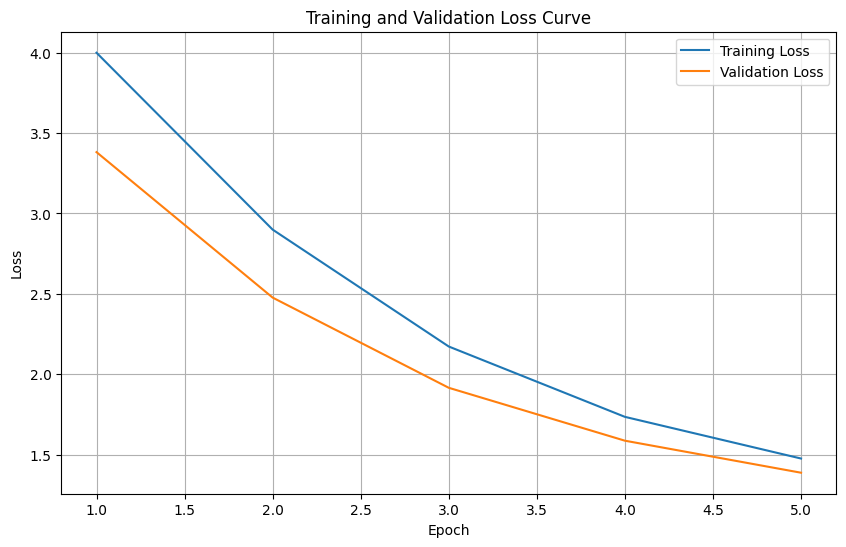

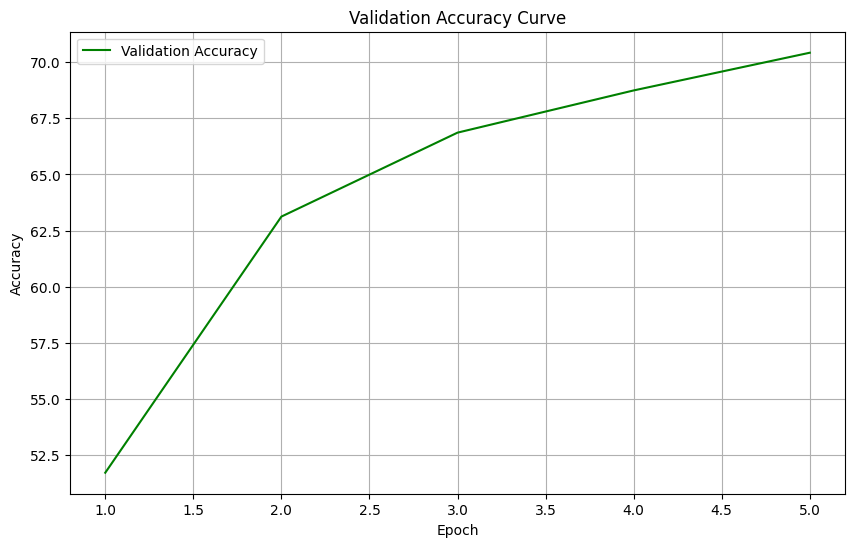

In [ ]:
import matplotlib.pyplot as plt

# Define epochs based on the length of the collected loss data
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()

# **Swin Transformer from scratch**

In [ ]:
# Hyperparameters

patch_size = 4
learning_rate = 0.001

num_heads = 3
num_layers = 4
hidden_dim = 96
mlp_dim = 384

In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_size, patch_size, in_channels=3, embed_dim=256):
        super().__init__()
        self.num_patches = (image_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim,
                            kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)  # [B, embed_dim, H', W']
        x = x.flatten(2)  # [B, embed_dim, num_patches]
        x = x.transpose(1, 2)  # [B, num_patches, embed_dim]
        return x

In [ ]:
# Transformer Encoder
class SmallTransformerEncoder(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, window_size=7, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.window_size = window_size

        self.layer_norm1 = nn.LayerNorm(embed_dim)

        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.layer_norm2 = nn.LayerNorm(embed_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )


    def window_partition(self, x):
        """
        x shape: [B, H, W, C]

        Returns:
        windows shape:
        [B * number_of_windows, window_size * window_size, C]
        """
        B, H, W, C = x.shape
        ws = self.window_size

        x = x.view(
            B,
            H // ws,
            ws,
            W // ws,
            ws,
            C
        )

        x = x.permute(0, 1, 3, 2, 4, 5).contiguous()

        windows = x.view(
            -1,
            ws * ws,
            C
        )

        return windows

    def window_reverse(self, windows, H, W, B):
        """
        windows shape:
        [B * number_of_windows, window_size * window_size, C]

        Returns:
        x shape: [B, H, W, C]
        """
        ws = self.window_size
        C = windows.shape[-1]

        x = windows.view(
            B,
            H // ws,
            W // ws,
            ws,
            ws,
            C
        )

        x = x.permute(0, 1, 3, 2, 4, 5).contiguous()

        x = x.view(B, H, W, C)

        return x

    def forward(self, x, H, W):
        """
        x shape: [B, H * W, C]
        """
        B, N, C = x.shape

        if N != H * W:
            raise ValueError(
                f"Number of tokens ({N}) must equal H * W ({H * W})."
            )

        if H % self.window_size != 0 or W % self.window_size != 0:
            raise ValueError(
                "H and W must be divisible by window_size."
            )

        shortcut = x

        # Layer normalization
        x = self.layer_norm1(x)

        # Convert token sequence into spatial feature map
        x = x.view(B, H, W, C)

        # Divide feature map into local windows
        windows = self.window_partition(x)

        # Self-attention is calculated separately inside each window
        attention_output, _ = self.attention(
            windows,
            windows,
            windows,
            need_weights=False
        )

        # Restore windows to the original spatial grid
        x = self.window_reverse(
            attention_output,
            H,
            W,
            B
        )

        # Convert back to token sequence
        x = x.view(B, H * W, C)

        # First residual connection
        x = shortcut + x

        # MLP portion
        shortcut = x
        x = self.layer_norm2(x)
        x = self.mlp(x)

        # Second residual connection
        x = shortcut + x

        return x

In [ ]:
class TinySwinTransformer(nn.Module):
    def __init__(
        self,
        image_size,
        patch_size,
        num_classes,
        embed_dim,
        num_heads,
        num_layers,
        mlp_dim,
        window_size=7,
        dropout=0.1
    ):
        super().__init__()

        self.image_size = image_size
        self.patch_size = patch_size

        # Spatial size after patch embedding
        self.patch_height = image_size // patch_size
        self.patch_width = image_size // patch_size

        self.patch_embed = PatchEmbedding(
            image_size,
            patch_size,
            3,
            embed_dim
        )

        self.dropout = nn.Dropout(dropout)

        # Window-attention blocks instead of global ViT blocks
        self.transformer = nn.ModuleList([
            SmallTransformerEncoder(
                embed_dim=embed_dim,
                num_heads=num_heads,
                mlp_dim=mlp_dim,
                window_size=window_size,
                dropout=dropout
            )
            for _ in range(num_layers)
        ])

        self.layer_norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # Patch embeddings: [B, H*W, embed_dim]
        x = self.patch_embed(x)
        x = self.dropout(x)

        H = self.patch_height
        W = self.patch_width

        # Each block performs attention inside local windows
        for transformer in self.transformer:
            x = transformer(x, H, W)

        x = self.layer_norm(x)

        # Global average pooling over all spatial tokens
        x = x.mean(dim=1)

        # CIFAR-100 classification
        x = self.head(x)

        return x

In [ ]:
model = TinySwinTransformer(
    image_size=224,
    patch_size=4,
    num_classes=100,
    embed_dim=96,
    num_heads=8,
    num_layers=8,
    mlp_dim=384,
    window_size=7,
    dropout=0.1
).to(device)

In [ ]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=5
)

In [ ]:
# loss.backward()

# torch.nn.utils.clip_grad_norm_(
#     model.parameters(),
#     max_norm=1.0
# )

# optimizer.step()

In [ ]:
def evaluate(model, data_loader, criterion, device, phase='Test'):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    inference_times = []

    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc=f'{phase} Phase'):
            images = images.to(device)
            labels = labels.to(device)

            start_time = time.time()
            outputs = model(images)
            end_time = time.time()

            inference_times.append(end_time - start_time)

            # Adapt to model output type: check if 'outputs' has a 'logits' attribute
            if hasattr(outputs, 'logits'):
                current_logits = outputs.logits
            else:
                current_logits = outputs

            loss = criterion(current_logits, labels)
            running_loss += loss.item()

            _, predicted = torch.max(current_logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = running_loss / len(data_loader)
    accuracy = 100 * correct / total
    avg_inference_time = sum(inference_times) / len(inference_times) if inference_times else 0

    print(f'{phase} Loss: {avg_loss:.4f}, {phase} Accuracy: {accuracy:.2f}%')
    print(f'Average Inference Time per Batch ({phase}): {avg_inference_time:.4f} seconds')

    return avg_loss, accuracy, avg_inference_time

In [ ]:
# Training loop
def train():
    print("\nStarting training...")
    start_time_total = time.time()

    # Lists to store metrics for plotting
    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_accuracies = []

    # Number of parameters (already calculated, but can be printed here for context)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total trainable parameters: {total_params}")

    # FLOPs (assuming thop is installed and calculated previously)
    dummy_input = torch.randn(1, 3, image_size, image_size).to(device)
    macs, params = profile(model, inputs=(dummy_input,), verbose=False)
    print(f"Average FLOPs (MACs): {macs / 1e9:.2f} GFLOPS")

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for i, (images, labels) in enumerate(tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs} Training')):
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels) # Use outputs directly

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        epoch_train_losses.append(avg_train_loss)
        print(f"Epoch {epoch + 1} finished. Average training loss: {avg_train_loss:.4f}")

        # Validation after each epoch
        val_loss, val_accuracy, avg_inference_time = evaluate(model, test_loader, criterion, device, phase='Validation')
        epoch_val_losses.append(val_loss)
        epoch_val_accuracies.append(val_accuracy)
        print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%')
        print(f'Average Inference Time per Batch (Validation): {avg_inference_time:.4f} seconds')

    end_time_total = time.time()
    print(f"\nTraining finished in {(end_time_total - start_time_total):.2f} seconds")
    print(f"Final Training Loss: {avg_train_loss:.4f}")

    return epoch_train_losses, epoch_val_losses, epoch_val_accuracies

In [ ]:
train_losses, val_losses, val_accuracies = train()


Starting training...
Total trainable parameters: 909316
Average FLOPs (MACs): 1.88 GFLOPS


Epoch 1/5 Training: 100%|██████████| 1563/1563 [03:01<00:00,  8.61it/s]


Epoch 1 finished. Average training loss: 4.0311


Validation Phase: 100%|██████████| 313/313 [00:13<00:00, 22.54it/s]


Validation Loss: 3.8285, Validation Accuracy: 11.14%
Average Inference Time per Batch (Validation): 0.0056 seconds
Validation Loss: 3.8285, Validation Accuracy: 11.14%
Average Inference Time per Batch (Validation): 0.0056 seconds


...

Validation Loss: 3.4762, Validation Accuracy: 16.66%
Average Inference Time per Batch (Validation): 0.0056 seconds
Validation Loss: 3.4762, Validation Accuracy: 16.66%
Average Inference Time per Batch (Validation): 0.0056 seconds


Epoch 5/5 Training: 100%|██████████| 1563/1563 [03:01<00:00,  8.61it/s]


Epoch 5 finished. Average training loss: 3.2700


Validation Phase: 100%|██████████| 313/313 [00:13<00:00, 22.49it/s]

Validation Loss: 3.3322, Validation Accuracy: 20.00%
Average Inference Time per Batch (Validation): 0.0057 seconds
Validation Loss: 3.3322, Validation Accuracy: 20.00%
Average Inference Time per Batch (Validation): 0.0057 seconds

Training finished in 976.73 seconds
Final Training Loss: 3.2700


In [ ]:
# Training loop
def train():
    from thop import profile # Added import for 'profile'
    print("\nStarting training...")
    start_time_total = time.time()

    # Lists to store metrics for plotting
    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_accuracies = []
    epoch_learning_rates = []

    # Number of trainable parameters
    total_params = sum(
        p.numel() for p in model.parameters() if p.requires_grad
    )
    print(f"Total trainable parameters: {total_params:,}")

    # FLOPs
    dummy_input = torch.randn(
        1, 3, image_size, image_size
    ).to(device)

    macs, params = profile(
        model,
        inputs=(dummy_input,),
        verbose=False
    )

    print(f"Average FLOPs (MACs): {macs / 1e9:.2f} GFLOPS")

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        # Record learning rate used during this epoch
        current_lr = optimizer.param_groups[0]["lr"]
        epoch_learning_rates.append(current_lr)

        for images, labels in tqdm(
            train_loader,
            desc=f"Epoch {epoch + 1}/{num_epochs} Training"
        ):
            images = images.to(device)
            labels = labels.to(device)

            # Clear previous gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            # Update model parameters
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        epoch_train_losses.append(avg_train_loss)

        print(
            f"Epoch {epoch + 1} finished. "
            f"Average training loss: {avg_train_loss:.4f}, "
            f"Learning rate: {current_lr:.6f}"
        )

        # Validation after each epoch
        val_loss, val_accuracy, avg_inference_time = evaluate(
            model,
            test_loader,
            criterion,
            device,
            phase="Validation"
        )

        epoch_val_losses.append(val_loss)
        epoch_val_accuracies.append(val_accuracy)

        print(
            f"Validation Loss: {val_loss:.4f}, "
            f"Validation Accuracy: {val_accuracy:.2f}%"
        )

        print(
            "Average Inference Time per Batch "
            f"(Validation): {avg_inference_time:.4f} seconds"
        )

        # Update learning rate after the epoch
        scheduler.step()

    end_time_total = time.time()
    total_training_time = end_time_total - start_time_total

    print(
        f"\nTraining finished in "
        f"{total_training_time:.2f} seconds"
    )
    print(f"Final Training Loss: {avg_train_loss:.4f}")

    return (
        epoch_train_losses,
        epoch_val_losses,
        epoch_val_accuracies,
        epoch_learning_rates
    )

In [ ]:
train_losses, val_losses, val_accuracies, learning_rates = train()


Starting training...
Total trainable parameters: 909,316
Average FLOPs (MACs): 1.88 GFLOPS


Epoch 1/5 Training: 100%|██████████| 1563/1563 [03:02<00:00,  8.59it/s]


Epoch 1 finished. Average training loss: 4.0402, Learning rate: 0.001000


Validation Phase: 100%|██████████| 313/313 [00:13<00:00, 22.54it/s]


Validation Loss: 3.8545, Validation Accuracy: 10.71%
Average Inference Time per Batch (Validation): 0.0060 seconds
Validation Loss: 3.8545, Validation Accuracy: 10.71%
Average Inference Time per Batch (Validation): 0.0060 seconds


...

Validation Loss: 3.4456, Validation Accuracy: 17.85%
Average Inference Time per Batch (Validation): 0.0060 seconds
Validation Loss: 3.4456, Validation Accuracy: 17.85%
Average Inference Time per Batch (Validation): 0.0060 seconds


Epoch 5/5 Training: 100%|██████████| 1563/1563 [03:01<00:00,  8.59it/s]


Epoch 5 finished. Average training loss: 3.2183, Learning rate: 0.000095


Validation Phase: 100%|██████████| 313/313 [00:13<00:00, 22.51it/s]

Validation Loss: 3.3683, Validation Accuracy: 19.39%
Average Inference Time per Batch (Validation): 0.0059 seconds
Validation Loss: 3.3683, Validation Accuracy: 19.39%
Average Inference Time per Batch (Validation): 0.0059 seconds

Training finished in 979.10 seconds
Final Training Loss: 3.2183


In [ ]:
print("\nFinal Evaluation on Test Set:")
test_loss, test_accuracy, test_inference_time = evaluate(model, test_loader, criterion, device, phase='Test')
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')
print(f'Average Inference Time per Batch (Test): {test_inference_time:.4f} seconds')


Final Evaluation on Test Set:


Test Phase: 100%|██████████| 313/313 [00:13<00:00, 22.42it/s]

Test Loss: 3.3322, Test Accuracy: 20.00%
Average Inference Time per Batch (Test): 0.0059 seconds
Test Loss: 3.3322, Test Accuracy: 20.00%
Average Inference Time per Batch (Test): 0.0059 seconds


In [ ]:
import torch
from thop import profile

# Calculate number of parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

# Calculate FLOPs
# We need a dummy input to calculate FLOPs.
# The input should match the expected input shape of the model.
dummy_input = torch.randn(1, 3, image_size, image_size).to(device)
macs, params = profile(model, inputs=(dummy_input,), verbose=False) # verbose=False to suppress detailed output
print(f"Average FLOPs (MACs): {macs / 1e9:.2f} GFLOPS") # Convert to GFLOPS

Total trainable parameters: 909316
Average FLOPs (MACs): 1.88 GFLOPS


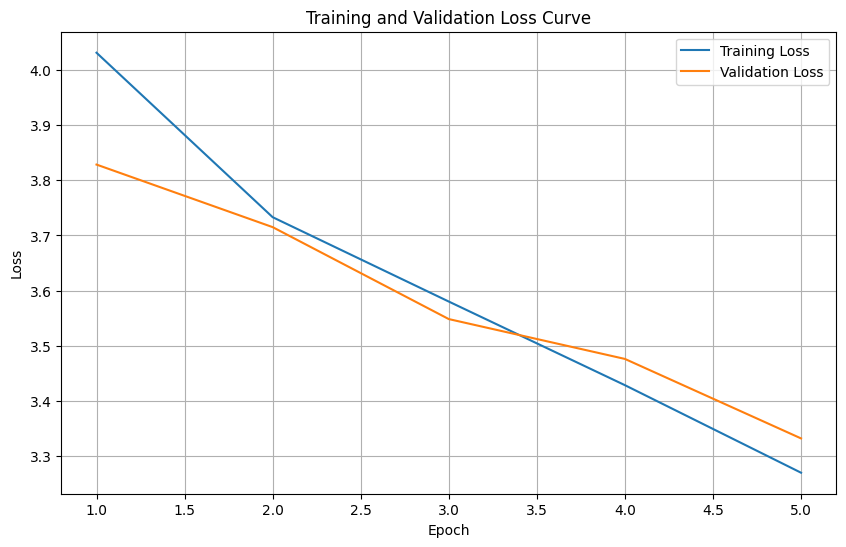

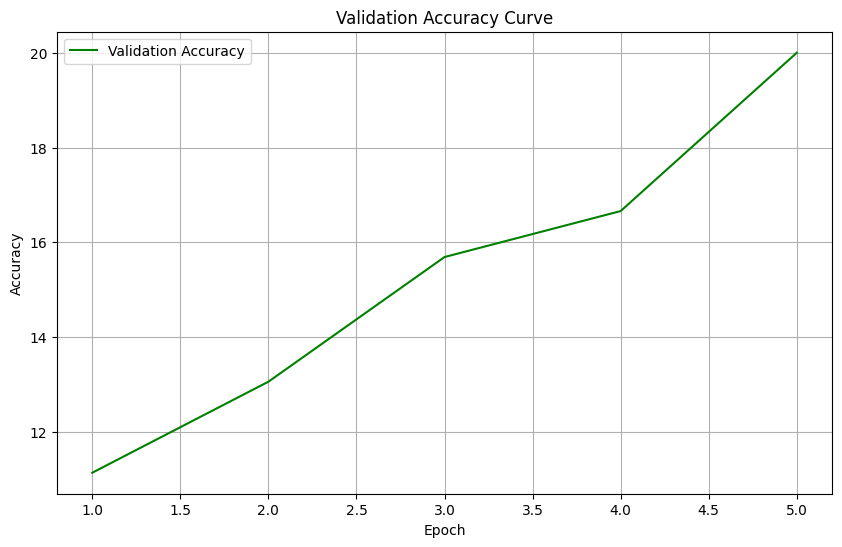

In [ ]:
import matplotlib.pyplot as plt

# Define epochs based on the length of the collected loss data
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()